In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
baseline = ds.pipeline.open(label="docs_default")
normalized = baseline["normalized"]
umap = baseline["umap"]

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

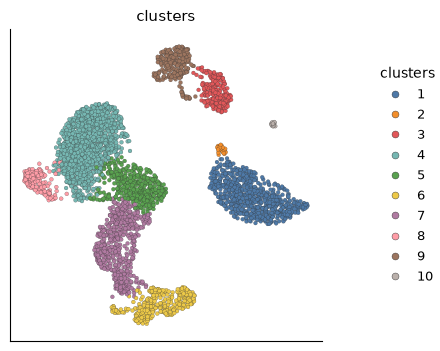

In [2]:
ds.plots.embedding(run=baseline, color_by="clusters")

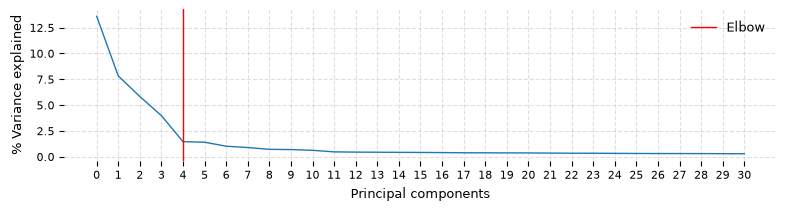

In [3]:
dimension_counts = (10, 15, 30)
graph_15 = baseline["connectivity_map"]
cluster_refs = {15: baseline["leiden_0.5"]}
for dimensions in (10, 30):
    pca = ds.run_pca(
        normalized,
        dims=dimensions,
        show_elbow_plot=dimensions == 30,
    )
    ann = ds.build_ann_index(pca)
    neighbors = ds.query_neighbors(ann, k=11)
    graph = ds.build_connectivity_map(neighbors)
    cluster_refs[dimensions] = ds.run_leiden_clustering(
        graph,
        resolution=0.5,
    )

initialization_15 = baseline["embedding_initialization"]
cluster_values = {
    dimensions: np.asarray(ds.load_artifact(cluster_refs[dimensions])["values"][:])
    for dimensions in dimension_counts
}

In [4]:
pd.DataFrame(
    {
        dimensions: pd.Series(cluster_values[dimensions]).value_counts()
        for dimensions in dimension_counts
    }
).fillna(0).astype(int)

,10,15,30
1,572,716,704
2,157,25,237
3,248,239,1315
4,619,1241,317
5,287,434,295
6,665,319,144
7,659,552,258
8,320,151,609
9,149,256,17
10,245,15,25


In [5]:
pd.Series(
    {
        f"{first} vs {second} PCs": ds.metric_label_concordance(
            cluster_refs[first], cluster_refs[second]
        )
        for first, second in combinations(dimension_counts, 2)
    },
    name="adjusted Rand index",
)

10 vs 15 PCs    0.636799
10 vs 30 PCs    0.652961
15 vs 30 PCs    0.832587
Name: adjusted Rand index, dtype: float64

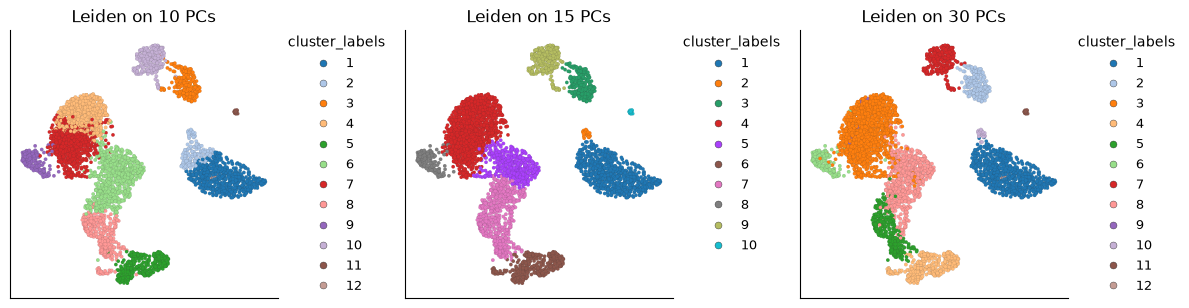

In [6]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, dimensions in zip(
    axes,
    dimension_counts,
    strict=True,
):
    ds.plots.embedding(
        layout=umap,
        color_by=cluster_refs[dimensions],
        target=axis,
        show_titles=False,
        show=False,
    )
    axis.set_title(f"Leiden on {dimensions} PCs")
figure.tight_layout()
figure

In [7]:
umap_tight = ds.run_umap(graph_15, initialization_15, min_dist=0.1)

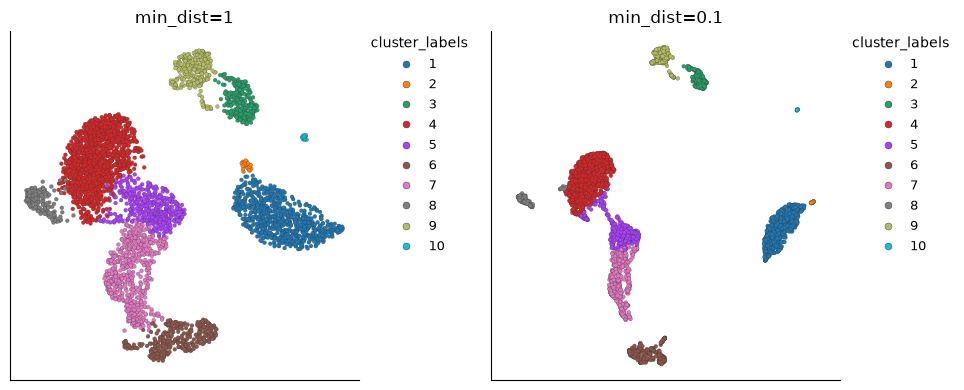

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, layout, title in zip(
    axes,
    (umap, umap_tight),
    ("min_dist=1", "min_dist=0.1"),
    strict=True,
):
    ds.plots.embedding(
        layout=layout,
        color_by=cluster_refs[15],
        target=axis,
        show_titles=False,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure

In [9]:
densmap = ds.run_umap(graph_15, initialization_15, use_density_map=True)

In [10]:
tsne = ds.run_tsne(graph_15, initialization_15, verbose=False)

Number of vertices: 3948


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 400: error is 3.00877 (50 iterations in 0.119872 seconds)


Iteration 450: error is 2.99828 (50 iterations in 0.146926 seconds)


Iteration 499: error is 2.99898 (50 iterations in 0.146744 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.208515 sec [21.4993%] |  Repulsive forces: 0.761352 sec [78.5007%]


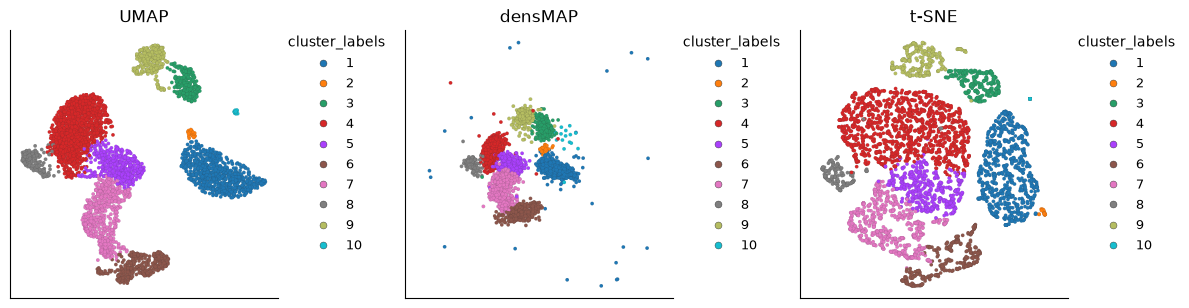

In [11]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
layout_comparisons = (
    ("UMAP", umap),
    ("densMAP", densmap),
    ("t-SNE", tsne),
)
for axis, (title, layout) in zip(
    axes,
    layout_comparisons,
    strict=True,
):
    ds.plots.embedding(
        layout=layout,
        color_by=cluster_refs[15],
        target=axis,
        show_titles=False,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure